# Problem 1
Find the first 5 Legendre polynomials.

In [133]:
import sympy as sp
from sympy import legendre, symbols, init_printing
init_printing()

z = symbols('z')

In [134]:
legendre(0, z)

In [135]:
legendre(1, z)

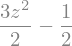

In [136]:
legendre(2, z)

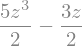

In [137]:
legendre(3, z)

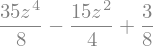

In [138]:
legendre(4, z)

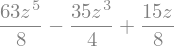

In [139]:
legendre(5, z)

# Problem 2
## Part 1
Find the Legendre expansion of $f(z)=\sin (\pi z)$.

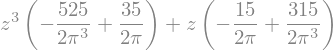

In [140]:
from sympy.abc import n


def get_legendre_coeff(f, n, z):
    # The normalization factor is (2n + 1) / 2
    coeff = ((2*n + 1) / 2) * sp.integrate(f * legendre(n, z), (z, -1, 1))
    return coeff

def get_legendre_expansion(f, N, z):
    f_expansion = sp.Sum(get_legendre_coeff(f, n, z) * legendre(n, z), (n, 0, N)).doit()
    return sp.collect(sp.Poly(f_expansion).as_expr(), z)

f = sp.sin(sp.pi * z)
f_expansion = get_legendre_expansion(f, 3, z)
f_expansion

Plotted with $f(z)$:

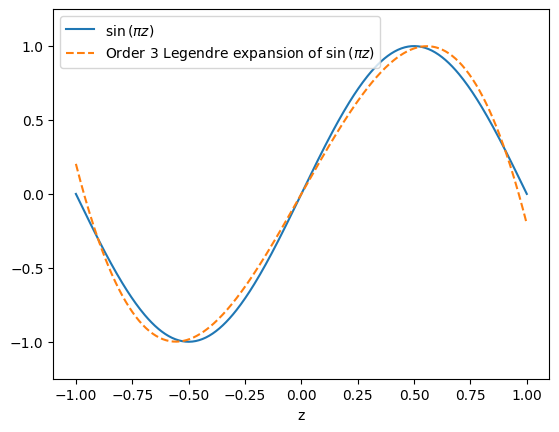

In [141]:
import numpy as np
import matplotlib.pyplot as plt


def plot_expansion(f, range, N):
    f_num = sp.lambdify(z, f, 'numpy')
    g_num = sp.lambdify(z, get_legendre_expansion(f, N, z), 'numpy')
    zs = np.linspace(range[0],range[1], 400)

    plt.plot(zs, f_num(zs), label=f'${sp.latex(f)}$')
    plt.plot(zs, g_num(zs), '--', label=f'Order {N} Legendre expansion of ${sp.latex(f)}$')

    plt.legend(loc='upper left')
    plt.xlabel('z')
    plt.ylim((-1.25,1.25))

    plt.show()

plot_expansion(f, (-1, 1), 3)

I can see that order 3 gets me quite close, and order 5 matches the functions almost completely. Let's try from $-2\leq z \leq 2$:


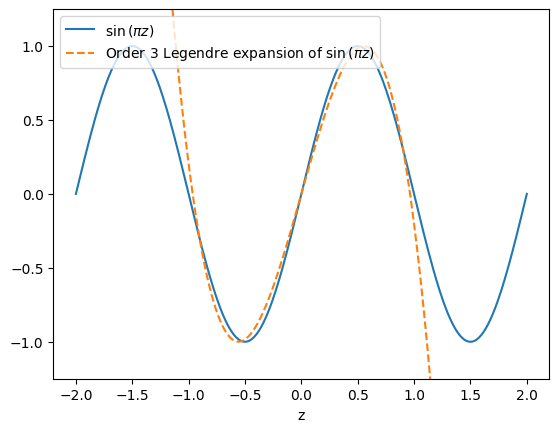

In [142]:
plot_expansion(f, (-2, 2), 3)

It seems like the solution diverges near the ends for the wider range. A larger value of $N$ does not help, because the range of convergence for a Legendre series is $-1 \leq z \leq 1$.

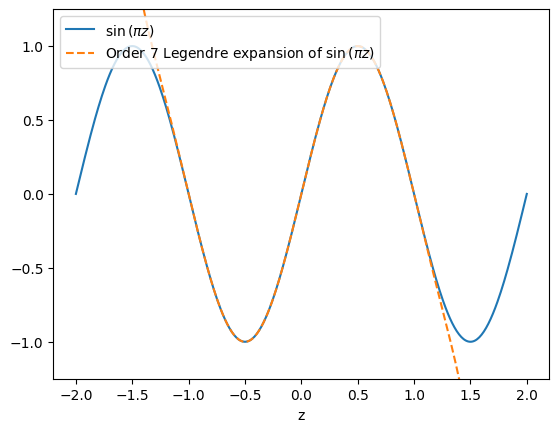

In [143]:
plot_expansion(f, (-2, 2), 7)

## Part 2
Find the Legendre expansion of $f(z)=\sin (3\pi z)$.

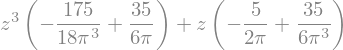

In [144]:
g = sp.sin(3*sp.pi * z)
g_expansion = get_legendre_expansion(g, 3, z)
g_expansion

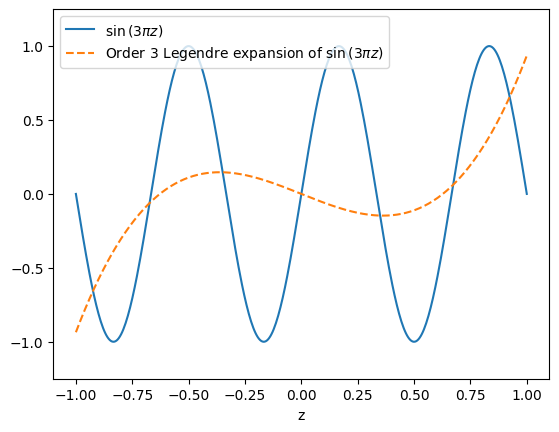

In [145]:
plot_expansion(g, (-1, 1), 3)

Not even close! Let's try a higher order:

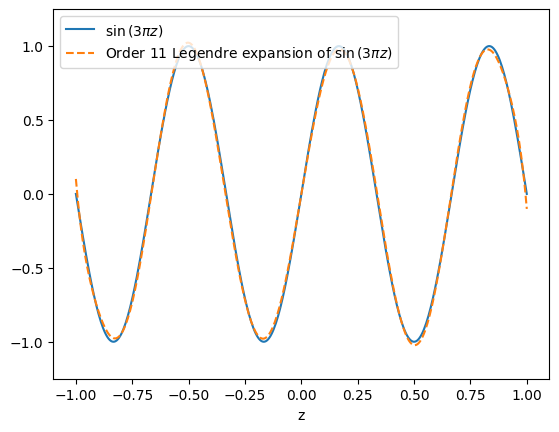

In [146]:
plot_expansion(g, (-1, 1), 11)

Again, the series should not converge for $2 \leq z \leq 2$:

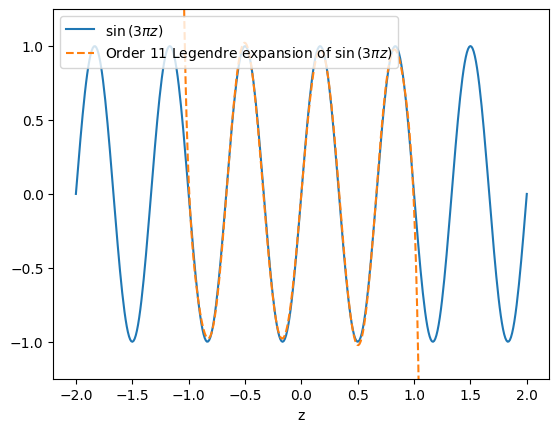

In [147]:
plot_expansion(g, (-2, 2), 11)